
===== CROSS-SESSION REACH-MODULATED HEATMAPS =====
  Session 1: 50 units shown / 78 reach-modulated / 98 total
  Session 2: 50 units shown / 177 reach-modulated / 189 total

Color scale: ±7.0


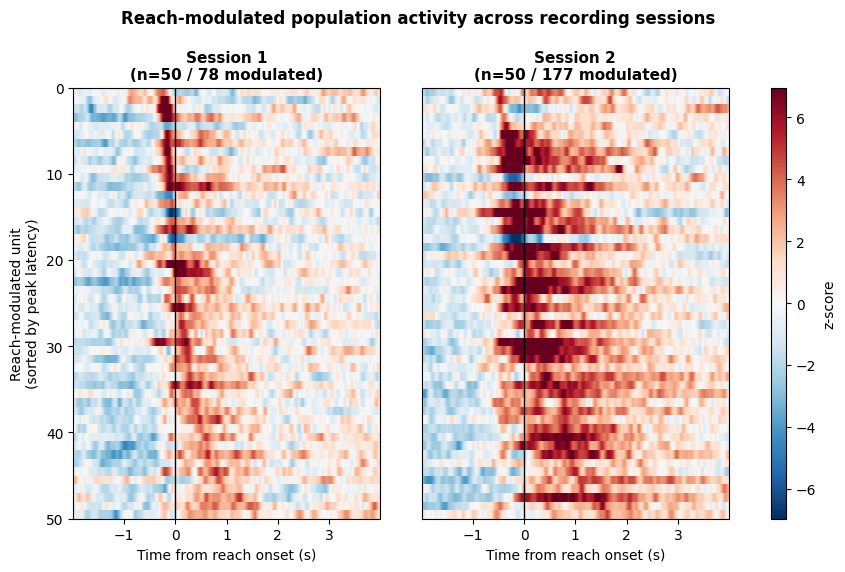


Saved → GRANT_per_session_heatmaps.png/.pdf/.svg

===== DONE =====



In [2]:
# ============================================================
# CROSS-SESSION REACH-MODULATED HEATMAPS (independent pools)
# ============================================================
# For each chosen session: sample N reach-modulated units (random),
# sort by peak latency within that session, plot heatmap.
# Different units per session. No cross-session matching.
# Purpose: "reach-modulated activity is present and structured on every
# recording day" — generic prelim credibility figure.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path

print("\n===== CROSS-SESSION REACH-MODULATED HEATMAPS =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
]
SESSION_LABELS = ["Session 1", "Session 2", "Session 3"]
OUTPUT_FOLDER = r"G:\Kevin\unit_matching"

N_UNITS_PER_SESSION = 50    # target sample size; caps at available count
RANDOM_SEED = 42
REACH_ARRAYS_NAME = "reach_good_in_trial_arrays.npz"   # Cell M-v3 output
# ------------------------------------------------------------

output_folder = Path(OUTPUT_FOLDER)
n_sessions = len(SESSION_ANALYSIS_FOLDERS)
rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# LOAD PER-SESSION Z-PSTHs FOR REACH-MODULATED UNITS
# ------------------------------------------------------------
session_data = []
for sf, lab in zip(SESSION_ANALYSIS_FOLDERS, SESSION_LABELS):
    af = Path(sf)
    ra_path = af / "qc" / REACH_ARRAYS_NAME
    if not ra_path.exists():
        raise FileNotFoundError(f"{ra_path} not found — run Cell M-v3 first.")
    ra = np.load(ra_path)
    units      = ra["units"]
    z_psth     = ra["z_mean"]
    modulated  = ra["modulated"]
    peak_lat   = None
    if "peak_latency" in ra.files:
        peak_lat = ra["peak_latency"]
    centers    = ra["centers"]

    mod_idx = np.where(modulated)[0]
    n_available = len(mod_idx)
    n_take = min(N_UNITS_PER_SESSION, n_available)
    if n_take < N_UNITS_PER_SESSION:
        print(f"  {lab}: only {n_available} reach-modulated units "
              f"(requested {N_UNITS_PER_SESSION}). Showing all.")
    chosen = rng.choice(mod_idx, size=n_take, replace=False)

    # If peak_latency wasn't stored, compute it on the fly from z_psth within response window
    if peak_lat is None:
        rwin = (-0.5, 2.0)
        resp_mask = (centers >= rwin[0]) & (centers < rwin[1])
        abs_z = np.abs(z_psth[chosen][:, resp_mask])
        peak_idx_in_resp = np.argmax(abs_z, axis=1)
        resp_centers = centers[resp_mask]
        chosen_peak_lat = resp_centers[peak_idx_in_resp]
    else:
        chosen_peak_lat = peak_lat[chosen]

    session_data.append({
        "label": lab,
        "z": z_psth[chosen],
        "peak_lat": chosen_peak_lat,
        "centers": centers,
        "n_units": n_take,
        "n_available": n_available,
        "total_units": len(units),
    })
    print(f"  {lab}: {n_take} units shown / {n_available} reach-modulated "
          f"/ {len(units)} total")

# Shared color scale (98th percentile of |z| across all chosen units, floored)
all_z = np.concatenate([d["z"].ravel() for d in session_data])
vmax = max(np.percentile(np.abs(all_z), 98), 3.0)
print(f"\nColor scale: ±{vmax:.1f}")

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig = plt.figure(figsize=(4.2 * n_sessions + 0.8, 5.6))
gs = GridSpec(1, n_sessions + 1,
              width_ratios=[1] * n_sessions + [0.05], wspace=0.20)

for si, d in enumerate(session_data):
    ax = fig.add_subplot(gs[0, si])
    order = np.argsort(d["peak_lat"])
    sorted_z = d["z"][order]
    im = ax.imshow(sorted_z, aspect="auto",
                   extent=[d["centers"][0], d["centers"][-1],
                           d["n_units"], 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=1.0)
    ax.set_xlabel("Time from reach onset (s)")
    if si == 0:
        ax.set_ylabel("Reach-modulated unit\n(sorted by peak latency)")
    else:
        ax.set_yticks([])
    ax.set_title(f"{d['label']}\n(n={d['n_units']} / {d['n_available']} modulated)",
                 fontsize=11, fontweight="bold")

cax = fig.add_subplot(gs[0, -1])
plt.colorbar(im, cax=cax, label="z-score")

plt.suptitle("Reach-modulated population activity across recording sessions",
             fontsize=12, fontweight="bold", y=1.02)

out_base = output_folder / "GRANT_per_session_heatmaps"
plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.pdf", bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.svg", bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved → {out_base.name}.png/.pdf/.svg")

print("\n===== DONE =====\n")